In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv("LIMFADD.csv")

print(df.shape)
df.head()

(15000, 11)


,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,N,N,N,0,N,Bot
1,2,505,252.5,0,0,N,Yes,N,0,N,Scam
2,6786,1782,0.262599469,1589,6051.040404,yes,N,Yes,10,N,Real
3,21,1281,61,0,0,N,Yes,N,0,N,Bot
4,585,1682,2.875213675,2663,926.1920333,yes,N,N,12,Yes,Real


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Followers            15000 non-null  int64
 1   Following            15000 non-null  int64
 2   Following/Followers  15000 non-null  int64
 3   Posts                15000 non-null  int64
 4   Posts/Followers      15000 non-null  int64
 5   Bio                  15000 non-null  int64
 6   Profile Picture      15000 non-null  int64
 7   External Link        15000 non-null  int64
 8   Mutual Friends       15000 non-null  int64
 9   Threads              15000 non-null  int64
 10  Labels               15000 non-null  int64
dtypes: int64(11)
memory usage: 1.3 MB


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [8]:
#INSPECTING THE DATA SET
df.info()

df.describe()

df['Labels'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Followers            15000 non-null  int64 
 1   Following            15000 non-null  int64 
 2   Following/Followers  15000 non-null  object
 3   Posts                15000 non-null  int64 
 4   Posts/Followers      15000 non-null  object
 5   Bio                  15000 non-null  object
 6   Profile Picture      15000 non-null  object
 7   External Link        15000 non-null  object
 8   Mutual Friends       15000 non-null  int64 
 9   Threads              15000 non-null  object
 10  Labels               15000 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.3+ MB


Labels
Bot     3750
Scam    3750
Real    3750
Spam    3750
Name: count, dtype: int64

In [22]:
#FOR  LABELS
df['Labels'].value_counts()

Labels
0    3750
2    3750
1    3750
3    3750
Name: count, dtype: int64

In [7]:

#DATA PROCESSING
#1. IDENTIFICATION OF CATEGORICAL COLUMN
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)


Index(['Following/Followers', 'Posts/Followers', 'Bio', 'Profile Picture',
       'External Link', 'Threads', 'Labels'],
      dtype='object')


In [11]:
#NCODING CATEGORICAL FEATURES
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [12]:
#DROPING CONSTANT FEATURES
constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print(constant_cols)

df.drop(columns=constant_cols, inplace=True)

[]


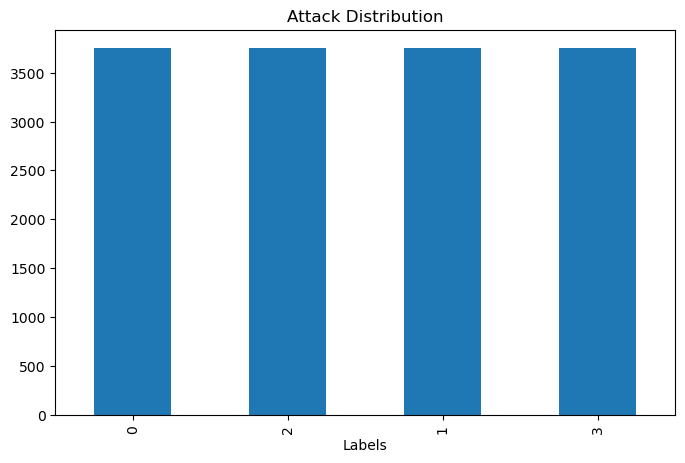

In [23]:
#EXPLORATORY DATA ANALYSIS
#Label Distribution
plt.figure(figsize=(8,5))

df['Labels'].value_counts().plot(
    kind='bar'
)

plt.title("Attack Distribution")
plt.show()

In [14]:
#NUMERIC FEATURES
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print(numeric_cols)

Index(['Followers', 'Following', 'Following/Followers', 'Posts',
       'Posts/Followers', 'Bio', 'Profile Picture', 'External Link',
       'Mutual Friends', 'Threads', 'Labels'],
      dtype='object')


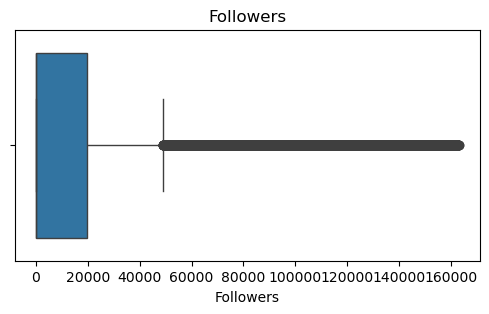

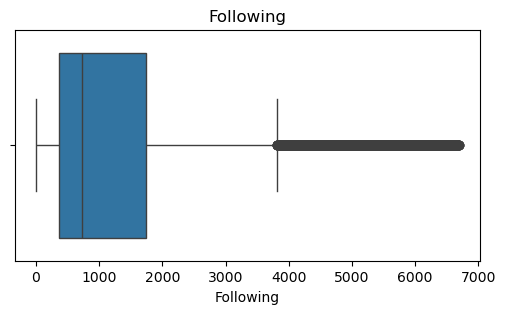

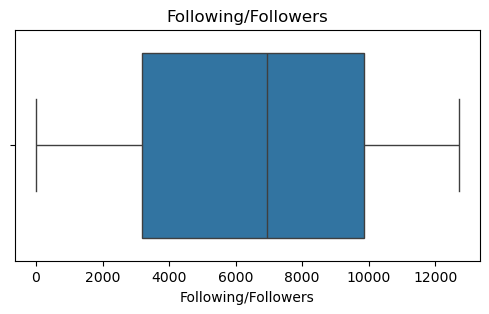

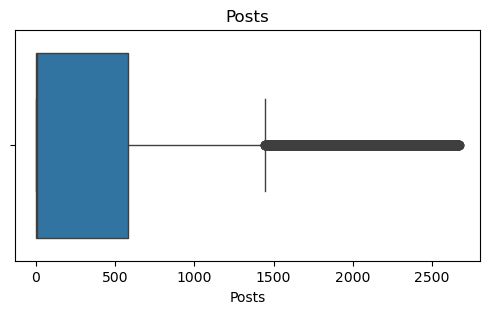

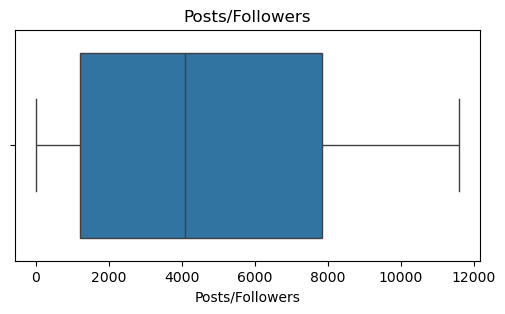

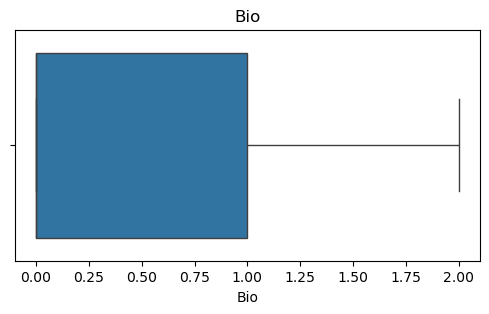

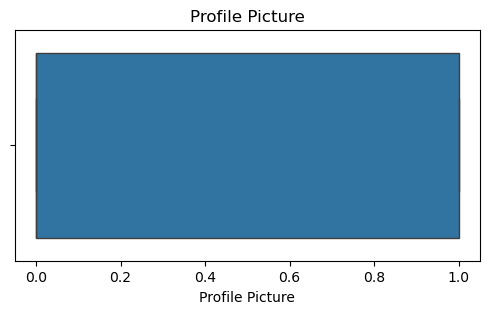

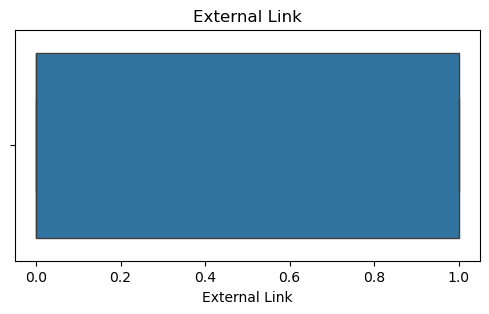

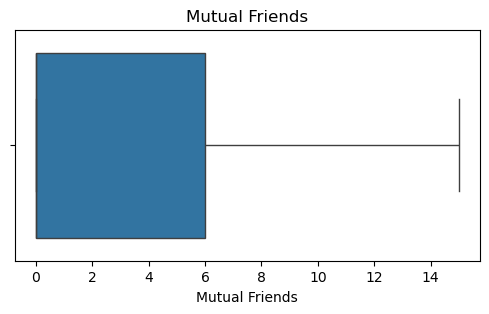

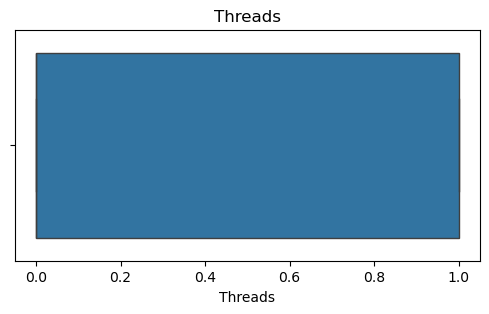

In [15]:
#BOXPLOTS
for col in numeric_cols[:10]:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [16]:
#IQR OUTLIER DETECTION
def detect_outliers_iqr(data):

    outliers = {}

    for col in data.columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = (
            (data[col] < lower) |
            (data[col] > upper)
        ).sum()

        outliers[col] = count

    return outliers

outliers = detect_outliers_iqr(
    df[numeric_cols]
)

outliers


{'Followers': np.int64(2649),
 'Following': np.int64(1678),
 'Following/Followers': np.int64(0),
 'Posts': np.int64(1727),
 'Posts/Followers': np.int64(0),
 'Bio': np.int64(0),
 'Profile Picture': np.int64(0),
 'External Link': np.int64(0),
 'Mutual Friends': np.int64(0),
 'Threads': np.int64(0),
 'Labels': np.int64(0)}

In [20]:
#MULTI CLASS CLASIFICATION 
#FEAtures AND TARGET 
X = df.drop(
    columns=['Labels', ]
)

y = df['Labels']

In [24]:

#TRAIN/VALIDATION /TEST
#TRAIN/VALIDATION /TEST

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [26]:
#FEATURE SCALING 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [29]:
#HYPERPARAMETER TUNING
rf = RandomForestClassifier(
    random_s#FEATURE SCALING 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)tate=42
)

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (46483608.py, line 4)

In [30]:
#BEST MODEL
best_rf = grid.best_estimator_

NameError: name 'grid' is not defined

In [31]:
#VALIDATION EVALUATION
val_pred = best_rf.predict(
    X_val_scaled
)

print(
    accuracy_score(
        y_val,
        val_pred
    )
)

print(
    classification_report(
        y_val,
        val_pred
    )
)

NameError: name 'best_rf' is not defined

In [35]:
y = df["Labels"]

In [36]:
X = df.drop(columns=["Labels"])

In [37]:
#Train / Validation / Test Split
from sklearn.model_selection import train_test_split

In [38]:
#train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [39]:
#validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [40]:
#Train a model (Random Forest)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:

#validation evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
y_val_pred = model.predict(X_val)

In [43]:
#accuray on validation test
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.9804444444444445


In [44]:
#complete classification report
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       562
           1       0.98      0.96      0.97       563
           2       0.98      1.00      0.99       562
           3       0.96      0.98      0.97       563

    accuracy                           0.98      2250
   macro avg       0.98      0.98      0.98      2250
weighted avg       0.98      0.98      0.98      2250



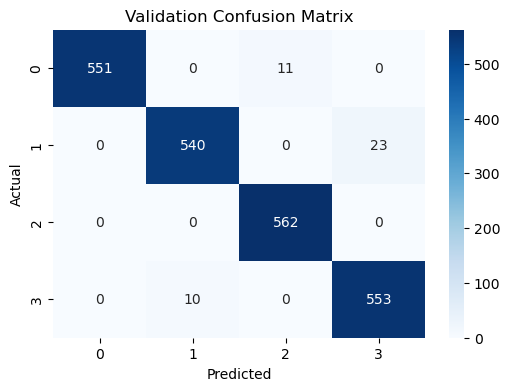

In [45]:
#using confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
y_train_pred = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

Train Accuracy: 0.9999047619047619


In [32]:
#TEST EVALUATION 
test_pred = best_rf.predict(
    X_test_scaled
)

print(
    accuracy_score(
        y_test,
        test_pred
    )
)

print(
    classification_report(
        y_test,
        test_pred
    )
)

NameError: name 'best_rf' is not defined

In [ ]:
#Binary Classification Version of Your Dataset

#We convert your Labels into:

#0 = Normal
#1 = Attack (anything else)

In [47]:
import pandas as pd
import numpy as np

df = pd.read_csv("LIMFADD.csv")

# Binary classification
df["Binary_Label"] = df["Labels"].apply(lambda x: 0 if x == 0 else 1)

df["Binary_Label"].value_counts()

Binary_Label
1    15000
Name: count, dtype: int64

In [48]:
#features and target
X = df.drop(columns=["Labels", "Binary_Label"])
y = df["Binary_Label"]

In [49]:
#TRAIN /VAL/SPLIT
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [50]:
#TRAIN MODEL
from sklearn.ensemble import RandomForestClassifier

binary_model = RandomForestClassifier(
    random_state=42
)

binary_model.fit(X_train, y_train)

ValueError: could not convert string to float: '#DIV/0!'

In [51]:
import numpy as np

df = df.replace("#DIV/0!", np.nan)

In [52]:
#CONVERTING COLUMNS TO NUMERIC
df = df.apply(pd.to_numeric, errors='coerce')

In [53]:
#FILLING THE MEDIAN
df = df.fillna(df.median())

In [54]:
#RECREATING X/Y
X = df.drop(columns=["Labels"])
y = df["Labels"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

ValueError: Input y contains NaN.

In [56]:
df = df.apply(pd.to_numeric, errors='coerce')

In [59]:

#CHEKING LABELS
print(df["Labels"].head())
print(df["Labels"].isna().sum())

0     Bot
1    Scam
2    Real
3     Bot
4    Real
Name: Labels, dtype: object
0


In [60]:
#CLEANING ONLY FEATURE COLUMNS NOT LABELS 
df = df.replace("#DIV/0!", np.nan)

feature_cols = df.columns.drop("Labels")

df[feature_cols] = df[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [61]:
#FIXING MY MISING VALUES
df[feature_cols] = df[feature_cols].fillna(
    df[feature_cols].median()
)

In [62]:
df = df.dropna(subset=["Labels"])


In [63]:
df["Labels"] = df["Labels"].astype(int)

ValueError: invalid literal for int() with base 10: 'Bot'

In [64]:
X = df.drop(columns=["Labels"])
y = df["Labels"]

In [65]:
#VERIFYING NAN
print(X.isna().sum().sum())  # should be 0
print(y.isna().sum())        # should be 0

60000
0


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [67]:
print(df["Labels"].unique()[:20])
print(df["Labels"].isna().sum())
print(df[df["Labels"].isna()])

['Bot' 'Scam' 'Real' 'Spam']
0
Empty DataFrame
Columns: [Followers, Following, Following/Followers, Posts, Posts/Followers, Bio, Profile Picture, External Link, Mutual Friends, Threads, Labels]
Index: []


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = binary_model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [70]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances (Binary Model)")
plt.show()

NameError: name 'feature_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [71]:
#HYPERPARAMETER TUNING (GRID SEARCH)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [72]:
#MODEL EVALUATION
best_model = grid.best_estimator_

val_pred = best_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.9742222222222222
              precision    recall  f1-score   support

         Bot       1.00      0.98      0.99       562
        Real       0.98      0.94      0.96       563
        Scam       0.98      1.00      0.99       562
        Spam       0.94      0.98      0.96       563

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250

